In [1]:
#Netflix Dataset Analysis

import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Set Seaborn style and palette
sns.set_style("whitegrid")
sns.set_palette("viridis")

In [3]:
# Load dataset
df = pd.read_csv(r"C:\Users\waniu\Downloads\python5th\python5th\Netflix_Dataset.csv")

# Standardize column names
df.columns = [c.strip() for c in df.columns]
df.head()


,Show_Id,Category,Title,Director,Cast,Country,Release_Date,Rating,Duration,Type,Description
0,s1,TV Show,3%,NaN,"João Miguel, Bianca Comparato, Michel Gomes, R...",Brazil,"August 14, 2020",TV-MA,4 Seasons,"International TV Shows, TV Dramas, TV Sci-Fi &...",In a future where the elite inhabit an island ...
1,s2,Movie,07:19,Jorge Michel Grau,"Demián Bichir, Héctor Bonilla, Oscar Serrano, ...",Mexico,"December 23, 2016",TV-MA,93 min,"Dramas, International Movies",After a devastating earthquake hits Mexico Cit...
2,s3,Movie,23:59,Gilbert Chan,"Tedd Chan, Stella Chung, Henley Hii, Lawrence ...",Singapore,"December 20, 2018",R,78 min,"Horror Movies, International Movies","When an army recruit is found dead, his fellow..."
3,s4,Movie,9,Shane Acker,"Elijah Wood, John C. Reilly, Jennifer Connelly...",United States,"November 16, 2017",PG-13,80 min,"Action & Adventure, Independent Movies, Sci-Fi...","In a postapocalyptic world, rag-doll robots hi..."
4,s5,Movie,21,Robert Luketic,"Jim Sturgess, Kevin Spacey, Kate Bosworth, Aar...",United States,"January 1, 2020",PG-13,123 min,Dramas,A brilliant group of students become card-coun...


In [6]:
# Check duplicates
print("Duplicate rows before cleaning:", df.duplicated().sum())

# Drop duplicates
df.drop_duplicates(inplace=True)
print("Duplicate rows after cleaning:", df.duplicated().sum())

# Fill missing values
df['Country'].fillna('Unknown', inplace=True)
df['Category'].fillna('Unknown', inplace=True)
df['Type'].fillna('', inplace=True)


Duplicate rows before cleaning: 0
Duplicate rows after cleaning: 0


C:\Users\waniu\AppData\Local\Temp\ipykernel_24324\3338833680.py:9: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df['Country'].fillna('Unknown', inplace=True)
C:\Users\waniu\AppData\Local\Temp\ipykernel_24324\3338833680.py:10: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For examp

In [7]:
# Clean 'Category' column
df['type_clean'] = df['Category'].astype(str).str.strip().str.title()

# Split genres and countries into lists
df['genres_list'] = df['Type'].astype(str).str.split(",").apply(lambda lst: [x.strip() for x in lst if x.strip() != ''])
df['country_list'] = df['Country'].astype(str).str.split(",").apply(lambda lst: [x.strip() for x in lst if x.strip() != ''])

# Extract release year
df['release_year'] = pd.to_numeric(df['Release_Date'].astype(str).str.extract(r'(\d{4})', expand=False), errors='coerce').astype('Int64')
dur = df['Duration'].astype(str).fillna("")

In [8]:


# Extract minutes and seasons
minutes = dur.str.extract(r'(\d+)\s*min', expand=False)
seasons = dur.str.extract(r'(\d+)\s*Season', expand=False)

df['duration_minutes'] = pd.NA
df['seasons'] = pd.NA
df.loc[minutes.notna(), 'duration_minutes'] = pd.to_numeric(minutes[minutes.notna()], errors='coerce').astype('Int64')
df.loc[seasons.notna(), 'seasons'] = pd.to_numeric(seasons[seasons.notna()], errors='coerce').astype('Int64')


In [9]:
# Explode genres
genres_exploded = df.explode('genres_list')
genres_exploded = genres_exploded[genres_exploded['genres_list'].notna() & (genres_exploded['genres_list'] != "")]
genres_exploded['genre'] = genres_exploded['genres_list'].astype(str)

# Explode countries
countries_exploded = df.explode('country_list')
countries_exploded = countries_exploded[countries_exploded['country_list'].notna() & (countries_exploded['country_list'] != "")]
countries_exploded['country'] = countries_exploded['country_list'].astype(str)


In [10]:
# Aggregations
type_year = df.groupby(['release_year', 'type_clean']).size().unstack(fill_value=0).sort_index()
top_genres = genres_exploded['genre'].value_counts().nlargest(20)
top_countries = countries_exploded['country'].value_counts().nlargest(20)

print("Row count:", df.shape[0])
print("\nTop genres (top 10):")
print(top_genres.head(10))
print("\nTop countries (top 10):")
print(top_countries.head(10))


Row count: 7787

Top genres (top 10):
genre
International Movies        2437
Dramas                      2106
Comedies                    1471
International TV Shows      1199
Documentaries                786
Action & Adventure           721
TV Dramas                    704
Independent Movies           673
Children & Family Movies     532
Romantic Movies              531
Name: count, dtype: int64

Top countries (top 10):
country
United States     3297
India              990
United Kingdom     723
Unknown            507
Canada             412
France             349
Japan              287
Spain              215
South Korea        212
Germany            199
Name: count, dtype: int64


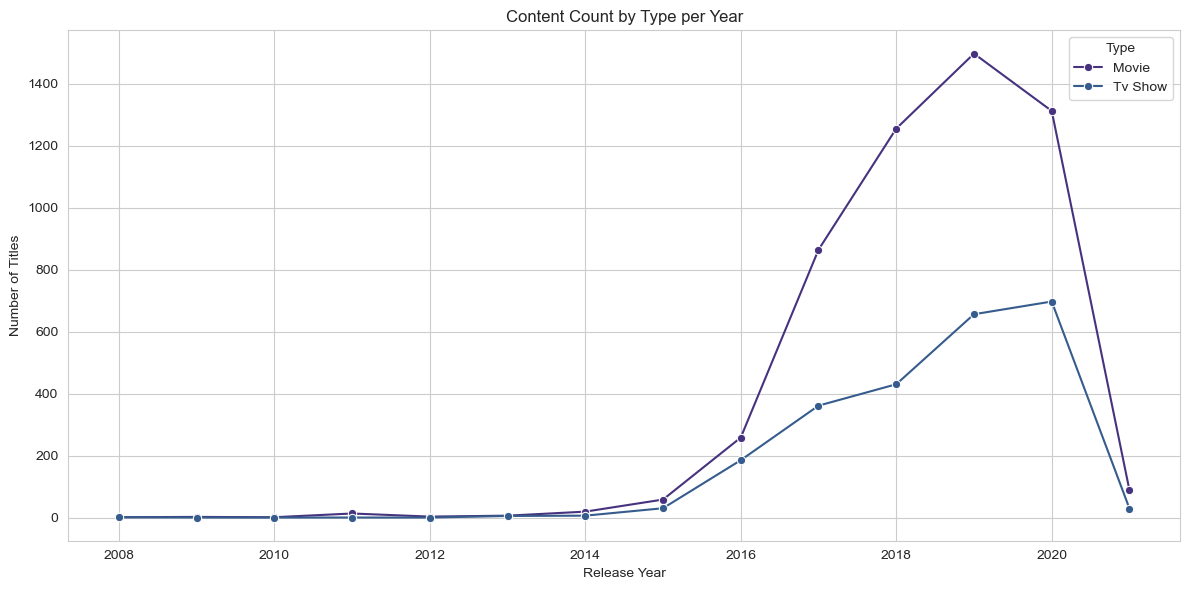

In [11]:
# Line plot: Number of movies vs TV shows per year
plt.figure(figsize=(12,6))
if not type_year.empty:
    type_year_reset = type_year.reset_index().melt(id_vars='release_year', value_name='count', var_name='Type')
    sns.lineplot(data=type_year_reset, x='release_year', y='count', hue='Type', marker="o")
    plt.xlabel("Release Year")
    plt.ylabel("Number of Titles")
    plt.title("Content Count by Type per Year")
    plt.legend(title="Type")
    plt.tight_layout()
    plt.show()


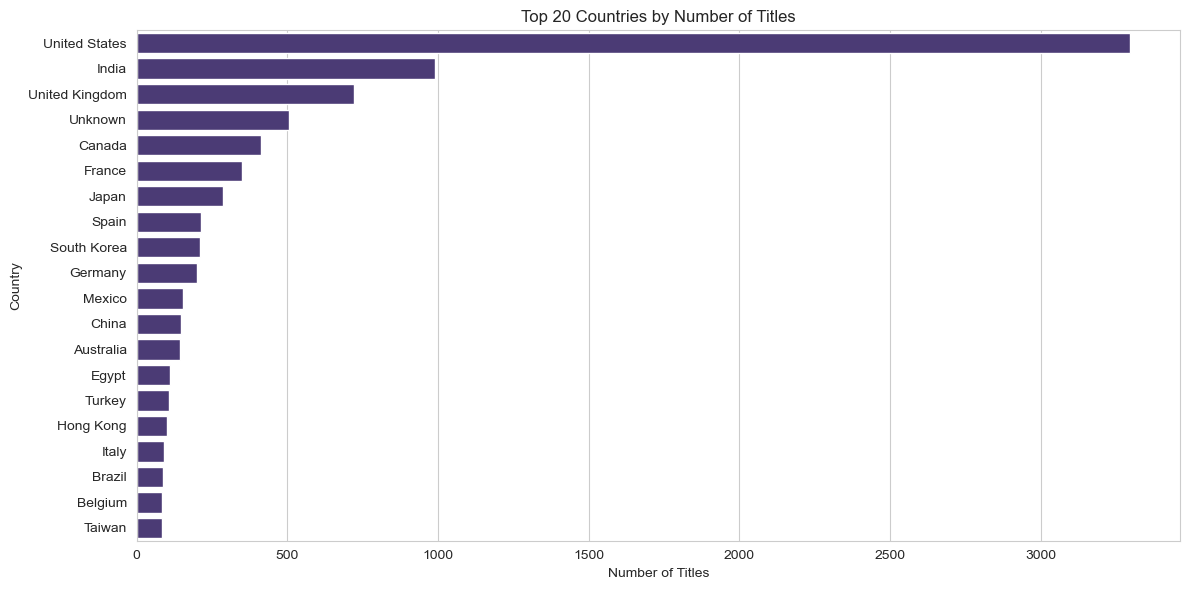

In [12]:
# Bar plot: Top 20 countries by number of titles
plt.figure(figsize=(12,6))
if not top_countries.empty:
    sns.barplot(x=top_countries.values, y=top_countries.index, orient='h')
    plt.xlabel("Number of Titles")
    plt.ylabel("Country")
    plt.title("Top 20 Countries by Number of Titles")
    plt.tight_layout()
    plt.show()


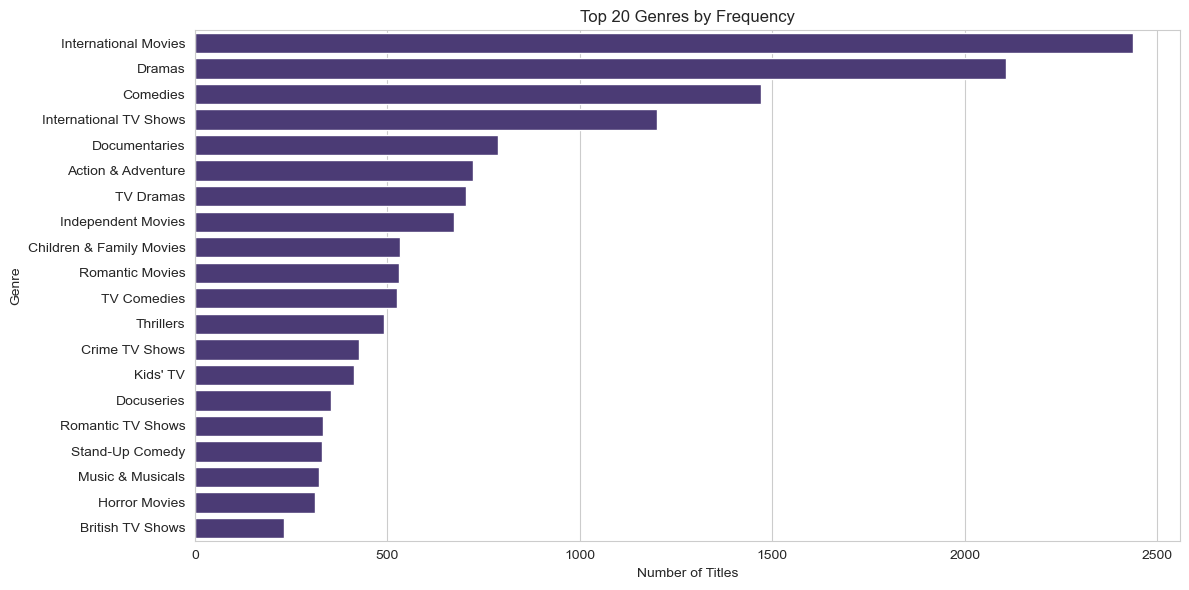

In [13]:
# Bar plot: Top 20 genres by frequency
plt.figure(figsize=(12,6))
if not top_genres.empty:
    sns.barplot(x=top_genres.values, y=top_genres.index, orient='h')
    plt.xlabel("Number of Titles")
    plt.ylabel("Genre")
    plt.title("Top 20 Genres by Frequency")
    plt.tight_layout()
    plt.show()


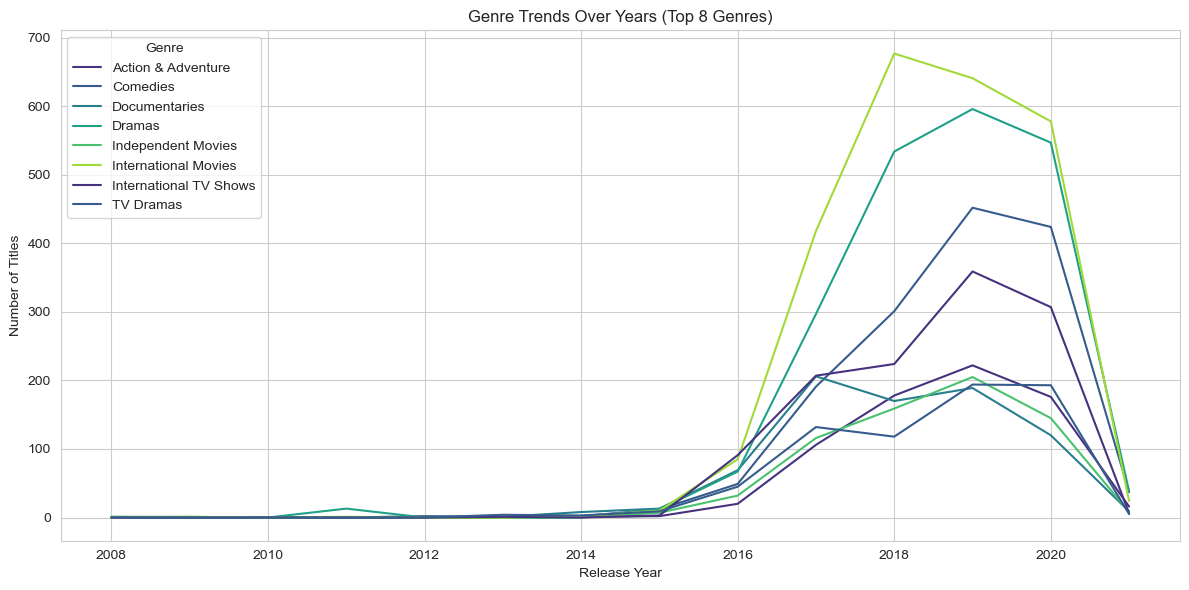

In [14]:
# Line plot: Trends for top 8 genres over years
top_genre_list = top_genres.index.tolist()[:8]
genre_year = genres_exploded.copy()
genre_year = genre_year[genre_year['genre'].isin(top_genre_list)]

if not genre_year.empty:
    # Group by year and genre
    genre_year = genre_year.groupby(['release_year','genre']).size().unstack(fill_value=0)
    
    # Reindex to include all years
    try:
        year_min = int(df['release_year'].min())
        year_max = int(df['release_year'].max())
        idx = range(year_min, year_max + 1)
        genre_year = genre_year.reindex(idx, fill_value=0)
    except Exception:
        pass
    
    # Plot each genre as a line
    plt.figure(figsize=(12,6))
    for genre in genre_year.columns:
        sns.lineplot(x=genre_year.index, y=genre_year[genre], label=genre)
    plt.xlabel("Release Year")
    plt.ylabel("Number of Titles")
    plt.title("Genre Trends Over Years (Top 8 Genres)")
    plt.legend(title="Genre")
    plt.tight_layout()
    plt.show()
